<a href="https://colab.research.google.com/github/owendouglas88/EMSC-W8-P1-u7947676/blob/main/Copy_of_EMSC2010_W8_P1_NB3_u7947676.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Question: In what year will the women's Olympic 100 m champion finish faster than the men's Olympic 100 m champion?

Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Input women's historical data where:
* ```W_year```: year of the women's Olympic final
* ```W_time```: time of the winner (in seconds)

In [2]:
W_year = np.array([1928,1932,1936,1948,1952,1956,1960,1964,1968,1972,1976,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016,2020,2024])
W_time = np.array([12.2,11.9,11.5,11.9,11.5,11.5,11,11.4,11.08,11.07,11.08,11.06,10.97,10.54,10.82,10.94,10.75,10.93,10.78,10.75,10.71,10.61,10.72])

Input men's historical data where:
* ```M_year```: year of the men's Olympic final
* ```M_time```: time of the winner (in seconds)

In [3]:
M_year = np.array([1900,1904,1908,1912,1920,1924,1928,1932,1936,1948,1952,1956,1960,1964,1968,1972,1976,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016,2020,2024])
M_time = np.array([11,11,10.8,10.8,10.8,10.6,10.8,10.3,10.3,10.3,10.4,10.5,10.5,10,9.95,10.14,10.06,10.25,9.99,9.92,9.96,9.84,9.87,9.85,9.69,9.63,9.81,9.8,9.79])

Visualize the historical data.

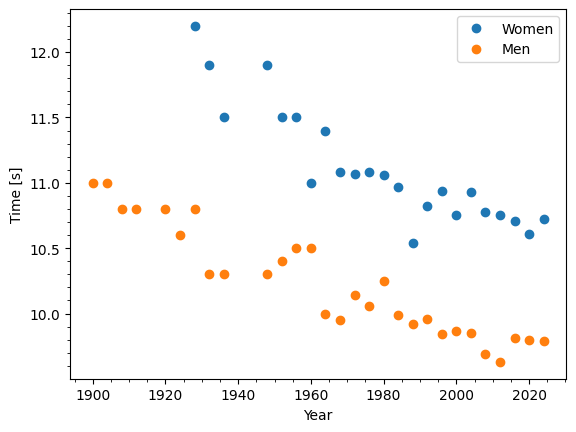

In [ ]:
plt.plot(W_year,W_time,'o',label = 'Women')
plt.plot(M_year,M_time,'o',label = 'Men')
plt.xlabel('Year')
plt.ylabel('Time [s]')
plt.legend()
plt.minorticks_on()
plt.show()

To simplify the problem, you can assume that both the women's and men's times follow a straight-line with respect to year.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

In [5]:
W_year = np.array([1928,1932,1936,1948,1952,1956,1960,1964,1968,1972,
                   1976,1980,1984,1988,1992,1996,2000,2004,2008,2012,
                   2016,2020,2024])
W_time = np.array([12.2,11.9,11.5,11.9,11.5,11.5,11,11.4,11.08,11.07,
                   11.08,11.06,10.97,10.54,10.82,10.94,10.75,10.93,10.78,
                   10.75,10.71,10.61,10.72])

M_year = np.array([1896,1900,1904,1906,1908,1912,1920,1924,1928,1932,
                   1936,1948,1952,1956,1960,1964,1968,1972,1976,1980,
                   1984,1988,1992,1996,2000,2004,2008,2012,2016,2020,2024])
M_time = np.array([12.0,11.0,11.0,11.2,10.8,10.8,10.8,10.6,10.8,10.3,
                   10.3,10.3,10.4,10.5,10.2,10.0,9.95,10.14,10.06,10.25,
                   9.99,9.92,9.96,9.84,9.87,9.85,9.69,9.63,9.81,9.80,9.79])

In [6]:
C_OFFSET = 1850

def log_model(year, a, b):
    """Logarithmic model: time = a - b * ln(year - C_OFFSET)"""
    return a - b * np.log(year - C_OFFSET)

In [7]:
w_params, w_cov = curve_fit(log_model, W_year, W_time, p0=[50, 5])
m_params, m_cov = curve_fit(log_model, M_year, M_time, p0=[50, 5])

w_a, w_b = w_params
m_a, m_b = m_params

print("=== Logarithmic Regression Results ===\n")
print(f"Women:  time = {w_a:.4f} - {w_b:.4f} * ln(year - {C_OFFSET})")
print(f"Men:    time = {m_a:.4f} - {m_b:.4f} * ln(year - {C_OFFSET})\n")

=== Logarithmic Regression Results ===

Women:  time = 19.4946 - 1.7330 * ln(year - 1850)
Men:    time = 16.0508 - 1.2391 * ln(year - 1850)



In [8]:
w_pred = log_model(W_year, *w_params)
m_pred = log_model(M_year, *m_params)

w_r2 = 1 - np.sum((W_time - w_pred)**2) / np.sum((W_time - np.mean(W_time))**2)
m_r2 = 1 - np.sum((M_time - m_pred)**2) / np.sum((M_time - np.mean(M_time))**2)

print(f"Women R² = {w_r2:.4f}")
print(f"Men   R² = {m_r2:.4f}\n")


Women R² = 0.8409
Men   R² = 0.8789



In [9]:
delta_a = m_a - w_a
delta_b = m_b - w_b

if abs(delta_b) < 1e-10:
    print("The two curves are parallel — no crossover.")
    crossover_year = None
else:
    ln_val = delta_a / delta_b
    crossover_year = np.exp(ln_val) + C_OFFSET
    if crossover_year > 2025:
        print(f"Projected crossover year: {crossover_year:.1f}")
    else:
        print("Crossover already occurred or curves diverge — check data.")

Projected crossover year: 2917.5


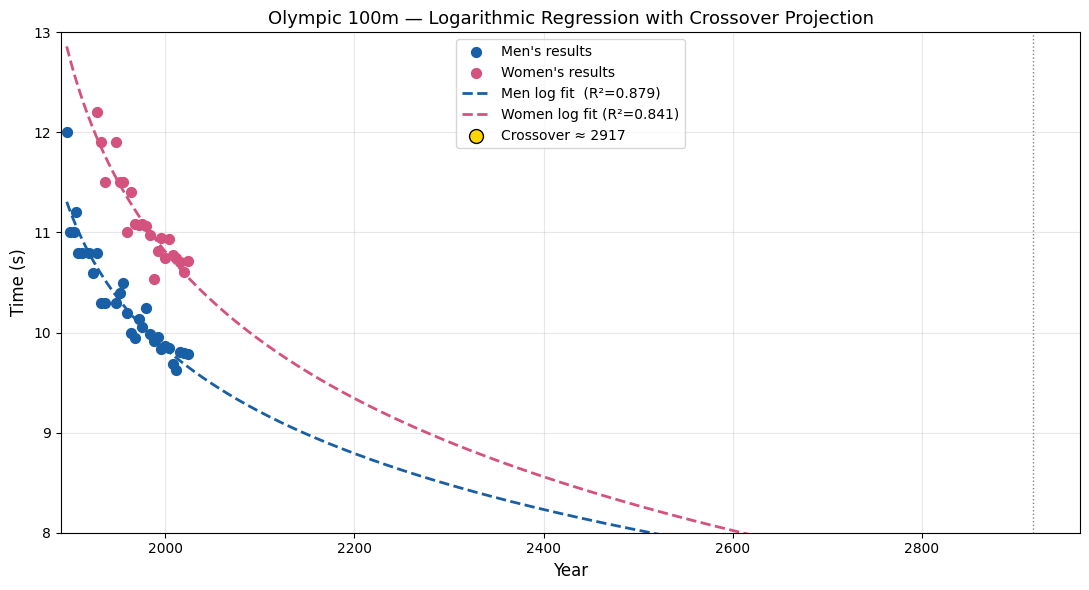


Plot saved to olympic_100m_log_regression.png


In [10]:
plot_end = int(crossover_year) + 50 if crossover_year else 2300
years_fit = np.linspace(1896, plot_end, 1000)

w_fit = log_model(years_fit, *w_params)
m_fit = log_model(years_fit, *m_params)

fig, ax = plt.subplots(figsize=(11, 6))

# Scatter data
ax.scatter(M_year, M_time, color='#185FA5', zorder=5, label="Men's results", s=50)
ax.scatter(W_year, W_time, color='#D4537E', zorder=5, label="Women's results", s=50)

# Logarithmic fits
ax.plot(years_fit, m_fit, color='#185FA5', linewidth=2,
        linestyle='--', label=f"Men log fit  (R²={m_r2:.3f})")
ax.plot(years_fit, w_fit, color='#D4537E', linewidth=2,
        linestyle='--', label=f"Women log fit (R²={w_r2:.3f})")

# Crossover marker
if crossover_year and 2024 < crossover_year < 3000:
    cross_time = log_model(crossover_year, *w_params)
    ax.axvline(crossover_year, color='gray', linewidth=1, linestyle=':')
    ax.scatter([crossover_year], [cross_time], color='gold', edgecolors='black',
               zorder=6, s=100, label=f"Crossover ≈ {crossover_year:.0f}")
    ax.annotate(f"~{crossover_year:.0f}", xy=(crossover_year, cross_time),
                xytext=(10, -15), textcoords='offset points', fontsize=10,
                color='black')

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Time (s)", fontsize=12)
ax.set_title("Olympic 100m — Logarithmic Regression with Crossover Projection", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(1890, plot_end)
ax.set_ylim(8.0, 13.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("olympic_100m_log_regression.png", dpi=150)
plt.show()
print("\nPlot saved to olympic_100m_log_regression.png")

In [11]:
cross_time = log_model(crossover_year, *w_params)
print(f"Time at crossover: {cross_time:.4f} seconds")

Time at crossover: 7.4104 seconds
